In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

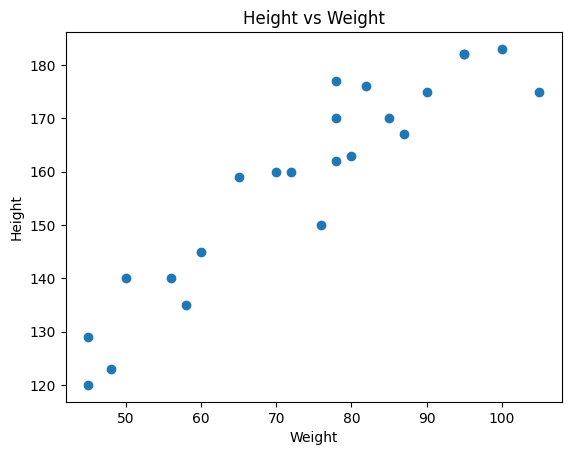

In [3]:
#scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')


In [4]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


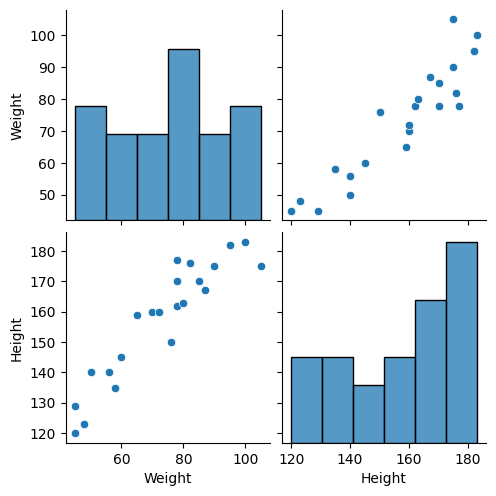

In [5]:
# Seaborn for visualization
import seaborn as sns

sns.pairplot(df)

In [ ]:
# Independent and dependent features
X = df[['Weight']] # independent features should be data frame or 2 dimesnionalarray
y = df['Height'] # this variable can be in series or 1d array

In [7]:
X_series = df['Weight'] # this will be series or 1d array

print("X_series shape:", np.array(X_series).shape)
print("y shape:", np.array(y).shape)

X_series shape: (23,)
y shape: (23,)


In [8]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [10]:
X_train = scaler.fit_transform(X_train)

In [11]:
X_test = scaler.transform(X_test)

In [12]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [14]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(n_jobs=-1)

regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [15]:
print("Coefficient Or Slope:", regressor.coef_)
print("Intercept:", regressor.intercept_)

Coefficient Or Slope: [17.2982057]
Intercept: 156.47058823529412


Text(0.5, 1.0, 'Height vs Weight (Training set)')

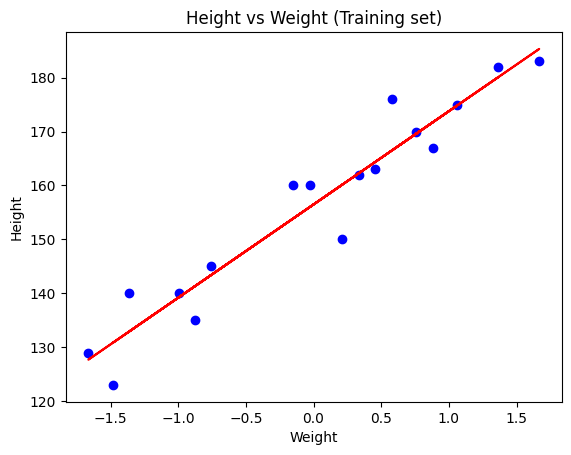

In [16]:
# plot Training data plot best fit line
plt.scatter(X_train, y_train, color='blue')

plt.plot(X_train, regressor.predict(X_train), color='red')

plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight (Training set)')

## prediction of test data
1. predicted height output= intercept +coef_(Weights)

2. y_pred_test =156.470 + 17.29(X_test)

In [17]:
# Prediction for test data
y_pred = regressor.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [18]:
# Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


## R square
Formula

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7360826717981276


## Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [20]:
# display adjusted R-squared

Adjusted_R2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score:", Adjusted_R2)

Adjusted R2 Score: 0.6701033397476595


In [22]:
# OLS Linear Regression
import statsmodels.api as sm

model = sm.OLS(y_train, X_train).fit()

predictions = model.predict(X_test)
print("Prediction:", predictions)

Prediction: [  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [23]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 20 Oct 2025   Prob (F-statistic):                       0.664
Time:                        07:07:47   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [24]:
# Prediction For new data
new_data = regressor.predict(scaler.transform([[50]]))
new_data

c:\Users\heman\Desktop\00 Complete Data Science,Machine Learning,DL,NLP Bootcamp By Krish Naik\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([132.92309646])